In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
# Loading the dataset
data = pd.read_csv("/content/Real estate.csv")
data.head(10)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
6,7,2012.667,34.5,623.47310,7,24.97933,121.53642,40.3
7,8,2013.417,20.3,287.60250,6,24.98042,121.54228,46.7
8,9,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8
9,10,2013.417,17.9,1783.18000,3,24.96731,121.51486,22.1


# New Section

In [7]:
# Check for duplicates
duplicates = data.duplicated().sum()
duplicates

np.int64(0)

In [8]:
# Calculate the number of non-null values in each column
null = data.notnull().sum()
null

,0
No,414
X1 transaction date,414
X2 house age,414
X3 distance to the nearest MRT station,414
X4 number of convenience stores,414
X5 latitude,414
X6 longitude,414
Y house price of unit area,414


In [9]:
data.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [10]:
# Retrieving the data types of each column
dtype = data.dtypes
dtype

,0
No,int64
X1 transaction date,float64
X2 house age,float64
X3 distance to the nearest MRT station,float64
X4 number of convenience stores,int64
X5 latitude,float64
X6 longitude,float64
Y house price of unit area,float64


In [11]:
x = data[['No','X1 transaction date','X2 house age','X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude']]
y = data['Y house price of unit area']

In [12]:
x.shape
y.shape

(414,)

In [13]:
# Split Data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
# Model Training
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

y_pred

array([47.04645871, 40.40783016, 43.37463978, 39.20600382, 26.62817953,
       45.8923956 , 44.33888897, 46.74448468, 24.43235155, 55.06258487,
       34.60848974, 36.92386329, 36.76420984, 24.30494918, 35.79519845,
       33.44810036, 44.24993318, 44.98654734, 29.18096544, 44.80711275,
        1.15259949, 36.10694406, 47.26486776, 45.90792727, 10.96198835,
       38.69069634, 12.57701679, 43.61237869, 35.7142565 , 37.55475044,
       14.14012034, 40.46209983, 35.90891223, 28.5174525 , 47.38286733,
       30.9022379 , 50.43545093, 12.92669013, 48.95222574, 39.27068588,
       39.3872837 , 40.09381011, 48.20107097, 37.08010208, 39.54765933,
       47.348201  , 43.3815801 , 21.07747224, 47.05299802, 44.57951775,
       48.24233055, 48.12297596, 41.42189435, 42.25141469, 36.32214409,
       15.69024514, 37.64733588, 35.12221291, 29.08561558, 46.86297981,
       32.07763941, 33.25961566, 15.22965501,  9.01697131,  9.37929873,
       33.78712833, 29.59931587, 47.50139803, 33.81312917, 31.84

In [15]:
# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [16]:
mse

54.60196067337693

In [17]:
mae

5.418035098629173

In [18]:
rmse

np.float64(7.389313951469171)

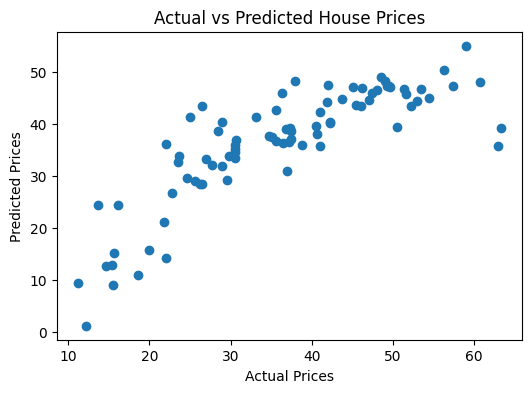

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [20]:
plt.figure(figsize=(6,6))

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

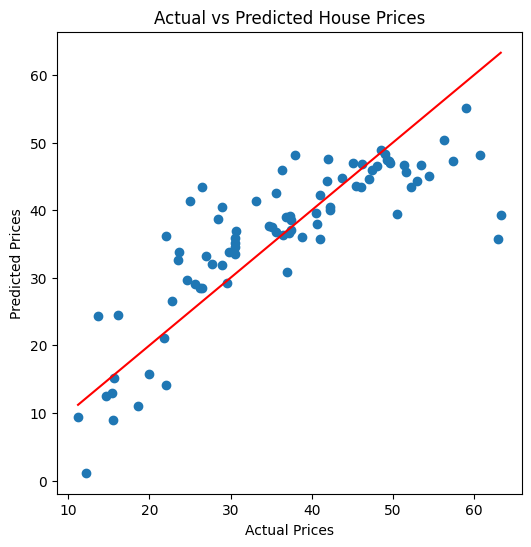

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
# Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

In [24]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("Random Forest Results:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest Results:
MAE: 3.8668554216867457
RMSE: 5.644398192173123


In [25]:
print("\nModel Comparison")
print("--------------------")

print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

print("\nLinear Regression MAE:", mae)
print("Random Forest MAE:", rf_mae)


Model Comparison
--------------------
Linear Regression RMSE: 7.389313951469171
Random Forest RMSE: 5.644398192173123

Linear Regression MAE: 5.418035098629173
Random Forest MAE: 3.8668554216867457


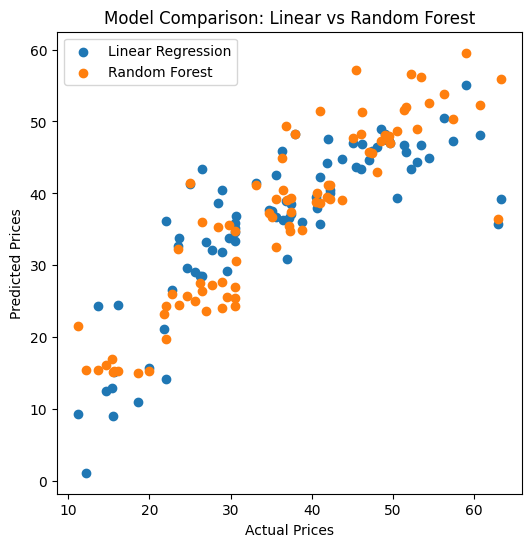

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, label="Linear Regression")
plt.scatter(y_test, rf_pred, label="Random Forest")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Model Comparison: Linear vs Random Forest")
plt.legend()
plt.show()